<a href="https://colab.research.google.com/github/farhanjutt2099-coder/Airline_AI_Project/blob/main/AirlineProject.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

**1. Load the Dataset**
* We begin by loading the dataset and inspecting its structure into our code.

In [ ]:
import pandas as pd

In [ ]:
import pandas as pd

# Load the dataset
df = pd.read_csv('/content/drive/MyDrive/Dataset/Airline.csv')
print(df)

        satisfaction  Gender      Customer Type  Age   Type of Travel  \
0          satisfied  Female     Loyal Customer   65  Personal Travel   
1          satisfied    Male     Loyal Customer   47  Personal Travel   
2          satisfied  Female     Loyal Customer   15  Personal Travel   
3          satisfied  Female     Loyal Customer   60  Personal Travel   
4          satisfied  Female     Loyal Customer   70  Personal Travel   
...              ...     ...                ...  ...              ...   
129875     satisfied  Female  disloyal Customer   29  Personal Travel   
129876  dissatisfied    Male  disloyal Customer   63  Personal Travel   
129877  dissatisfied    Male  disloyal Customer   69  Personal Travel   
129878  dissatisfied    Male  disloyal Customer   66  Personal Travel   
129879  dissatisfied  Female  disloyal Customer   38  Personal Travel   

           Class  Flight Distance  Seat comfort  \
0            Eco              265             0   
1       Business     

# New Section

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [ ]:
# Check the first few rows
print(df.head())

  satisfaction  Gender   Customer Type  Age   Type of Travel     Class  \
0    satisfied  Female  Loyal Customer   65  Personal Travel       Eco   
1    satisfied    Male  Loyal Customer   47  Personal Travel  Business   
2    satisfied  Female  Loyal Customer   15  Personal Travel       Eco   
3    satisfied  Female  Loyal Customer   60  Personal Travel       Eco   
4    satisfied  Female  Loyal Customer   70  Personal Travel       Eco   

   Flight Distance  Seat comfort  Departure/Arrival time convenient  \
0              265             0                                  0   
1             2464             0                                  0   
2             2138             0                                  0   
3              623             0                                  0   
4              354             0                                  0   

   Food and drink  ...  Online support  Ease of Online booking  \
0               0  ...               2                       3

In [ ]:
# Check for data types and missing values
print(df.info())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 129880 entries, 0 to 129879
Data columns (total 23 columns):
 #   Column                             Non-Null Count   Dtype  
---  ------                             --------------   -----  
 0   satisfaction                       129880 non-null  object 
 1   Gender                             129880 non-null  object 
 2   Customer Type                      129880 non-null  object 
 3   Age                                129880 non-null  int64  
 4   Type of Travel                     129880 non-null  object 
 5   Class                              129880 non-null  object 
 6   Flight Distance                    129880 non-null  int64  
 7   Seat comfort                       129880 non-null  int64  
 8   Departure/Arrival time convenient  129880 non-null  int64  
 9   Food and drink                     129880 non-null  int64  
 10  Gate location                      129880 non-null  int64  
 11  Inflight wifi service              1298

**2. Handling Missing Values**
* It’s important to handle missing values before moving forward. We'll inspect the dataset for missing values and decide how to handle them.

In [ ]:
# Option 1: Drop rows with missing values (if missing values are small in number)
df_cleaned = df.dropna()

In [ ]:
 #import pandas as pd

# Load the dataset (assuming the dataset is already loaded into df)
# df = pd.read_csv('your_file.csv')

# Check for missing values in the entire dataset
print("Missing values before handling:")
print(df.isnull().sum())

# Choose one of the following two options:

# Option 1: Fill missing values in 'Arrival Delay in Minutes' with the mean
df['Arrival Delay in Minutes'].fillna(df['Arrival Delay in Minutes'].mean(), inplace=True)

# Option 2: Alternatively, fill with the median (uncomment if preferred)
# df['Arrival Delay in Minutes'].fillna(df['Arrival Delay in Minutes'].median(), inplace=True)

# Option 3: If you want to remove rows with missing values in 'Arrival Delay in Minutes' (uncomment if preferred)
# df_cleaned = df.dropna(subset=['Arrival Delay in Minutes'])

# Check for missing values after handling
print("\nMissing values after handling:")
print(df.isnull().sum())  # Should show no missing values for 'Arrival Delay in Minutes'


Missing values before handling:
satisfaction                           0
Gender                                 0
Customer Type                          0
Age                                    0
Type of Travel                         0
Class                                  0
Flight Distance                        0
Seat comfort                           0
Departure/Arrival time convenient      0
Food and drink                         0
Gate location                          0
Inflight wifi service                  0
Inflight entertainment                 0
Online support                         0
Ease of Online booking                 0
On-board service                       0
Leg room service                       0
Baggage handling                       0
Checkin service                        0
Cleanliness                            0
Online boarding                        0
Departure Delay in Minutes             0
Arrival Delay in Minutes             393
dtype: int64

Missing val

/tmp/ipykernel_1330/3796544058.py:13: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df['Arrival Delay in Minutes'].fillna(df['Arrival Delay in Minutes'].mean(), inplace=True)


**3. Encoding Categorical Data**
* Many machine learning algorithms require categorical data to be converted into numerical format. We’ll use One-Hot Encoding to handle categorical features like "Gender," "Class," etc.

In [ ]:
# Convert categorical features into dummy variables (One-Hot Encoding)
df_encoded = pd.get_dummies(df, drop_first=True)

# View the encoded dataset
print(df_encoded.head())

   Age  Flight Distance  Seat comfort  Departure/Arrival time convenient  \
0   65              265             0                                  0   
1   47             2464             0                                  0   
2   15             2138             0                                  0   
3   60              623             0                                  0   
4   70              354             0                                  0   

   Food and drink  Gate location  Inflight wifi service  \
0               0              2                      2   
1               0              3                      0   
2               0              3                      2   
3               0              3                      3   
4               0              3                      4   

   Inflight entertainment  Online support  Ease of Online booking  ...  \
0                       4               2                       3  ...   
1                       2               

**4. Feature Scaling**
* To ensure that all numerical features are on the same scale, apply Standardization or Min-Max Scaling.

In [ ]:
from sklearn.preprocessing import StandardScaler
# Identify numerical columns for scaling
# Original: numerical_columns = ['Flight Distance', 'Arrival Delay', 'Departure Delay']

# Check if columns exist before scaling
existing_columns = df_encoded.columns

# Updated numerical_columns with only existing columns in the DataFrame
numerical_columns = [col for col in ['Flight Distance', 'Arrival Delay', 'Departure Delay'] if col in existing_columns]

# Print a message if any columns were excluded
excluded_columns = [col for col in ['Flight Distance', 'Arrival Delay', 'Departure Delay'] if col not in existing_columns]
if excluded_columns:
    print(f"Warning: The following columns were excluded because they are not in the DataFrame: {excluded_columns}")

# Apply Standard Scaling
scaler = StandardScaler()
df_encoded[numerical_columns] = scaler.fit_transform(df_encoded[numerical_columns])

# View the scaled dataset
print(df_encoded.head())


   Age  Flight Distance  Seat comfort  Departure/Arrival time convenient  \
0   65        -1.671103             0                                  0   
1   47         0.469852             0                                  0   
2   15         0.152458             0                                  0   
3   60        -1.322552             0                                  0   
4   70        -1.584452             0                                  0   

   Food and drink  Gate location  Inflight wifi service  \
0               0              2                      2   
1               0              3                      0   
2               0              3                      2   
3               0              3                      3   
4               0              3                      4   

   Inflight entertainment  Online support  Ease of Online booking  ...  \
0                       4               2                       3  ...   
1                       2               

**5. Splitting the Data into Training and Testing Sets**
* Now we split the dataset into features (X) and target (y), and then split it into training and testing sets.

In [ ]:
# Define the features (X) and target (y)
# Check if 'Satisfaction' or its one-hot encoded columns exist
satisfaction_column_name = None
# Iterate over all columns to find a potential match (case-insensitive)
for col in df_encoded.columns:
    if "satisfaction" in col.lower():
        satisfaction_column_name = col
        break  # Stop if a match is found

if satisfaction_column_name:
    X = df_encoded.drop(satisfaction_column_name, axis=1)
    y = df_encoded[satisfaction_column_name]
else:
    raise KeyError("'Satisfaction' column (or its one-hot encoded version) not found in df_encoded.")

# Import train_test_split from sklearn.model_selection
from sklearn.model_selection import train_test_split

# Split the dataset into training and testing sets (80% train, 20% test)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)




**6. Training the Logistic Regression Model**
* Once the data is prepared, we can train a Logistic Regression model.

In [ ]:
from sklearn.linear_model import LogisticRegression

# Initialize the Logistic Regression model
lr_model = LogisticRegression()

# Train the model on the training data
lr_model.fit(X_train, y_train)

# Predict on the test set
y_pred = lr_model.predict(X_test)

/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:465: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


**7. Model Evaluation**
* We evaluate the model performance using metrics such as accuracy, precision, recall, and F1-score.

In [ ]:
from sklearn.metrics import accuracy_score, classification_report
import matplotlib.pyplot as plt

# Evaluate model accuracy
accuracy = accuracy_score(y_test, y_pred)
print(f'Accuracy: {accuracy}')

# Display the classification report
print(classification_report(y_test, y_pred))
#plt.show()

Accuracy: 0.8270326455189405
              precision    recall  f1-score   support

       False       0.82      0.79      0.80     11675
        True       0.84      0.85      0.84     14301

    accuracy                           0.83     25976
   macro avg       0.83      0.82      0.82     25976
weighted avg       0.83      0.83      0.83     25976



<>:16: SyntaxWarning: invalid escape sequence '\s'
<>:16: SyntaxWarning: invalid escape sequence '\s'
/tmp/ipykernel_1330/2893574523.py:16: SyntaxWarning: invalid escape sequence '\s'
  report_df = pd.read_csv(StringIO(report_str), sep='\s{2,}', engine='python', header=0, index_col=0)
/tmp/ipykernel_1330/2893574523.py:37: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=report_df.index, y=metric, data=report_df, ax=axes[i], palette='viridis')
/tmp/ipykernel_1330/2893574523.py:37: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=report_df.index, y=metric, data=report_df, ax=axes[i], palette='viridis')


Classification Report:
               precision    recall  f1-score   support

       False       0.82      0.79      0.80     11675
        True       0.84      0.85      0.84     14301

    accuracy                           0.83     25976
   macro avg       0.83      0.82      0.82     25976
weighted avg       0.83      0.83      0.83     25976



/tmp/ipykernel_1330/2893574523.py:37: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=report_df.index, y=metric, data=report_df, ax=axes[i], palette='viridis')


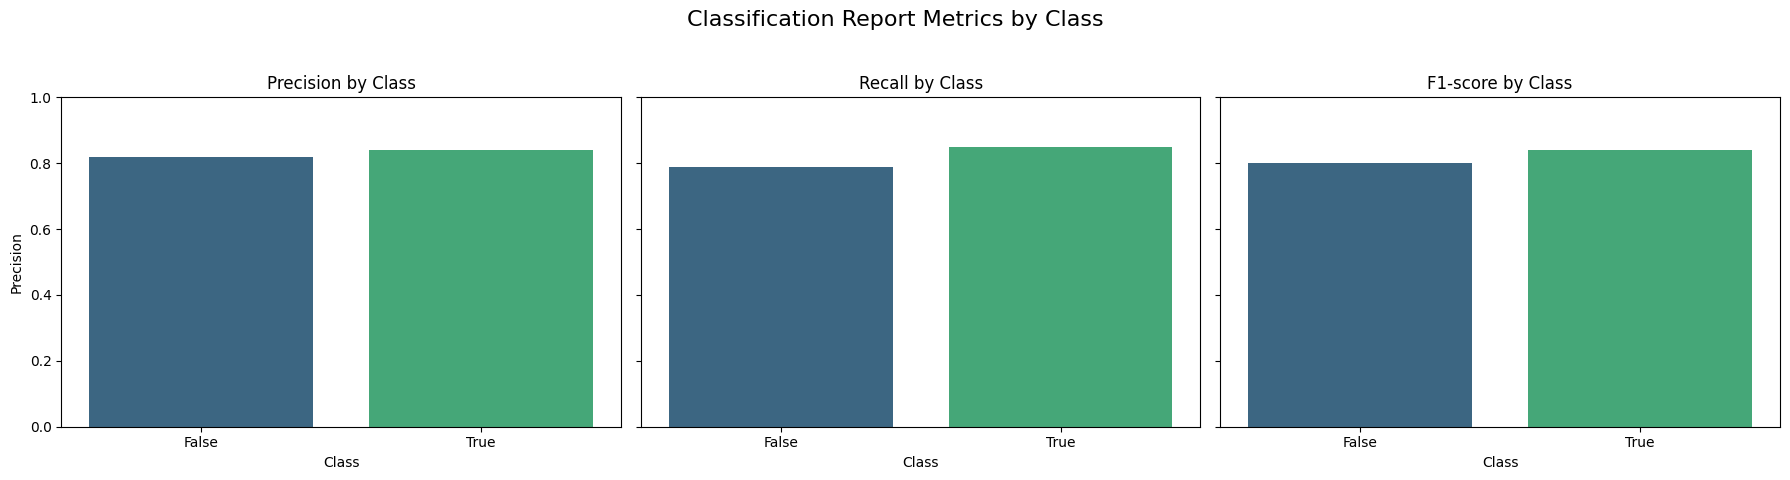

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns
from io import StringIO


# Assuming 'classification_report' was printed to stdout. We can re-run it
# and capture the output if needed, or if it's already captured, use that.
# For this example, let's regenerate the report to ensure we capture it.

report_str = classification_report(y_test, y_pred, output_dict=False)
print("Classification Report:\n", report_str)

#report_str = classification_report(y_test, y_pred, output_dict=False)
#print("Classificition Report:/n", report_str)
# Parse the classification report string
report_df = pd.read_csv(StringIO(report_str), sep='\s{2,}', engine='python', header=0, index_col=0)

# The last two rows are 'accuracy' and 'macro avg'/'weighted avg', which are not class-specific
# We want to plot precision, recall, f1-score for each class (True/False or 0/1)
# Filter out 'accuracy', 'macro avg', 'weighted avg' rows
#The last row are 'accuracy and 'macro avg'/'weghted avg', which are not class-specfic
#we want to plot precision, recall, f1-score for each class (true/false or 0/1)
#Filter out 'accuraacy and macro avg'/'weighted avg' rows.
report_df = report_df.iloc[:-3]

#report_df = reports_df.iloc[:-3]
# convert index to string for plotting if it's boolean
# Convert index to string for plotting if it's boolean
report_df.index = report_df.index.astype(str)

# Plotting the metrics
metrics = ['precision', 'recall', 'f1-score']
fig, axes = plt.subplots(1, len(metrics), figsize=(18, 5), sharey=True)
fig.suptitle('Classification Report Metrics by Class', fontsize=16)

for i, metric in enumerate(metrics):
    sns.barplot(x=report_df.index, y=metric, data=report_df, ax=axes[i], palette='viridis')
    axes[i].set_title(f'{metric.capitalize()} by Class')
    axes[i].set_xlabel('Class')
    axes[i].set_ylabel(metric.capitalize())
    axes[i].set_ylim(0, 1) # Metrics are between 0 and 1

plt.tight_layout(rect=[0, 0.03, 1, 0.95])
plt.show()